# 📈 Notebook 2 – Exploratory Data Analysis (EDA)

**Project:** EcoType – Forest Cover Type Prediction  
**Objective:** Perform univariate and bivariate analysis, visualize feature distributions, class relationships, correlations, and baseline feature importances.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv("../data/processed/capped_forest_cover_data.csv")
print(f"✅ Loaded cleaned data: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

✅ Loaded cleaned data: 145,890 rows × 13 columns


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596.0,51,3,258.0,0,510,221.0,232,148,6279,Aspen,1,29
1,2590.0,56,2,212.0,-6,390,220.0,235,151,6225,Aspen,1,29
2,2804.0,139,9,268.0,65,3180,234.0,238,135,6121,Lodgepole Pine,1,12
3,2785.0,155,18,242.0,117,3090,238.0,238,122,6211,Lodgepole Pine,1,30
4,2595.0,45,2,153.0,-1,391,220.0,234,150,6172,Aspen,1,29


---
## 5️⃣ Exploratory Data Analysis

### 5.1 Univariate Analysis – Feature Distributions

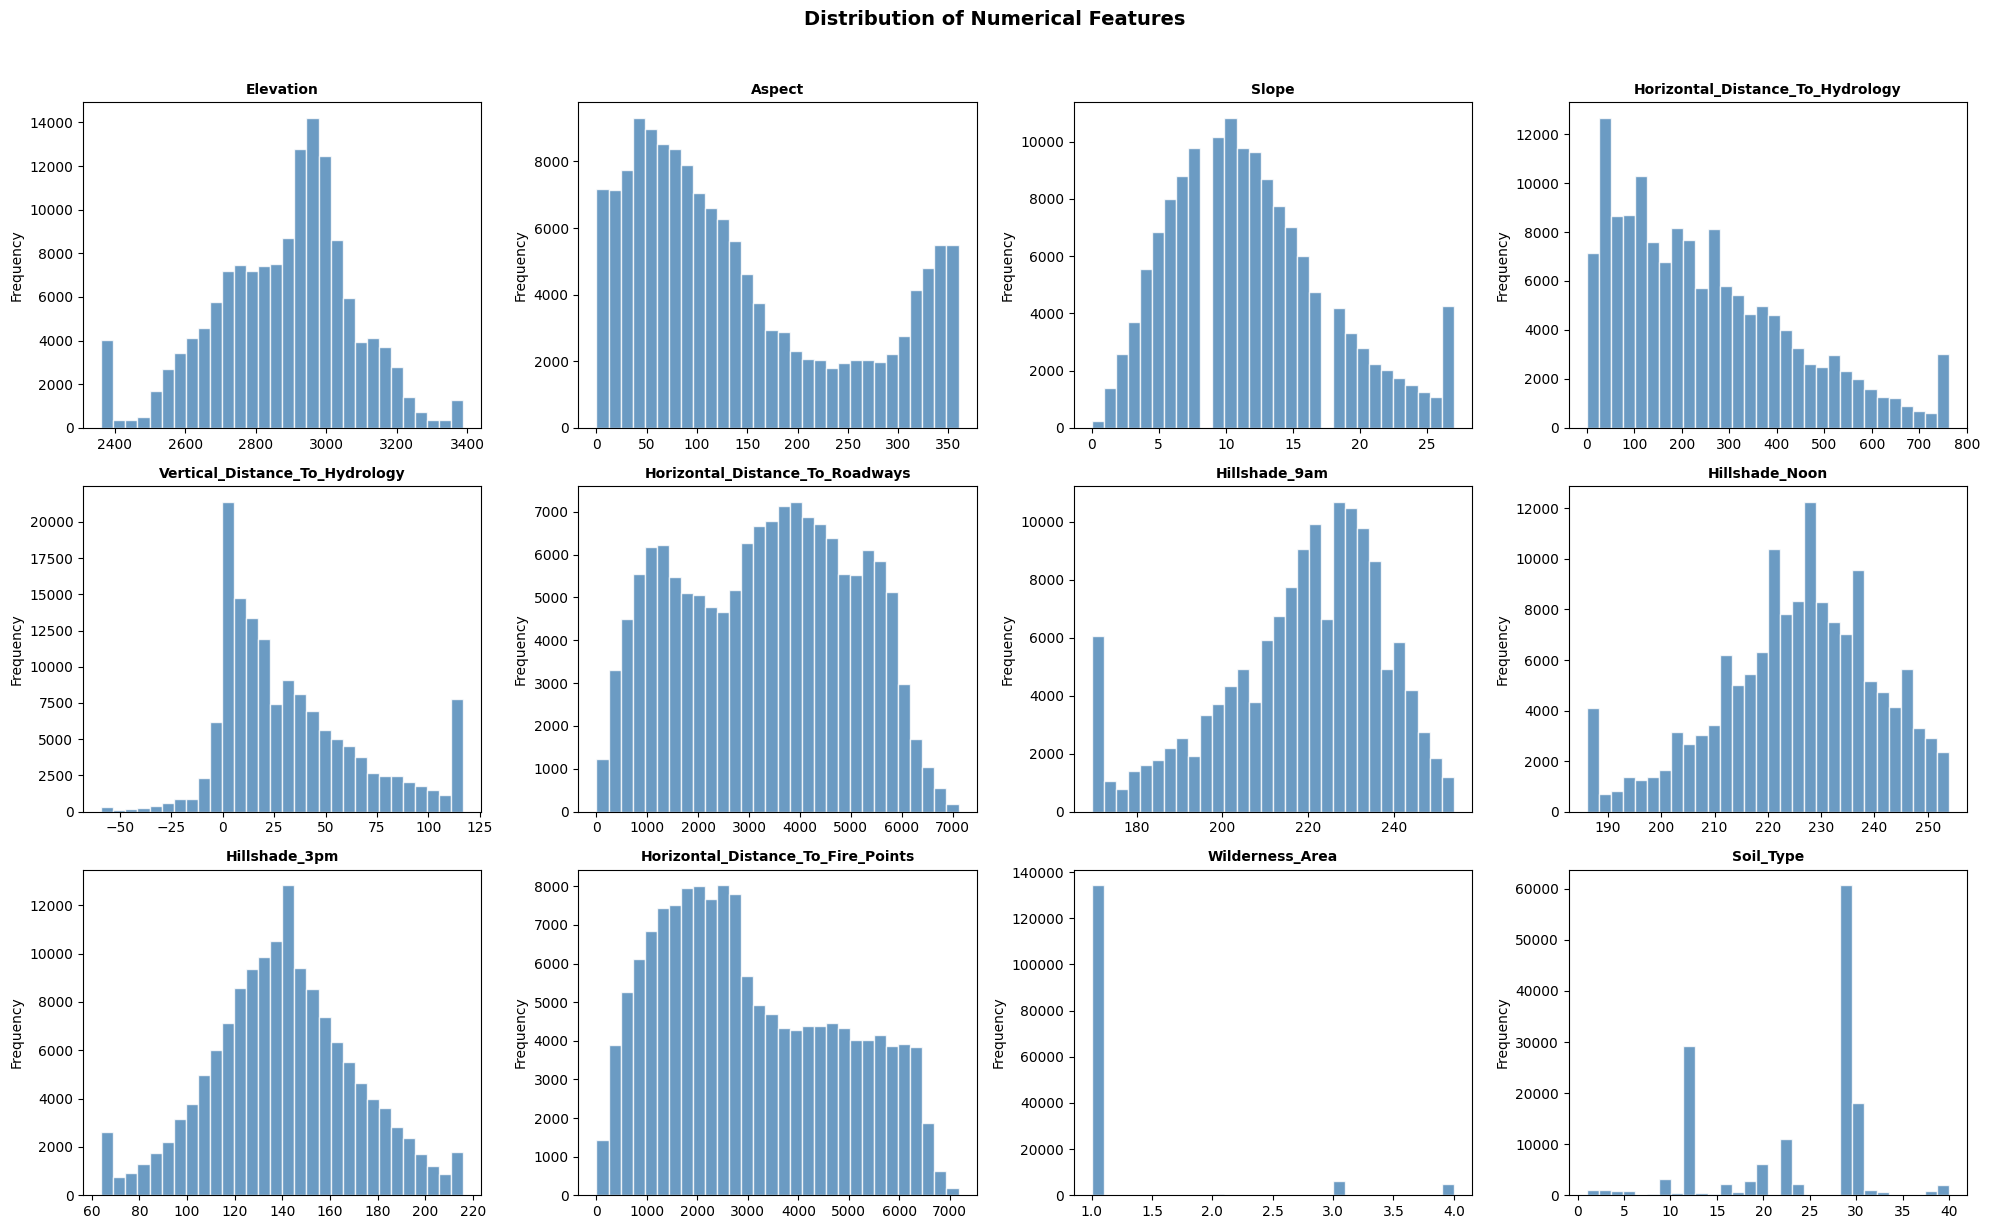

In [2]:
# Histograms for all numeric features
num_cols = df.select_dtypes(include='number').columns.tolist()
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frequency')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Distribution of Numerical Features", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Target Variable Distribution

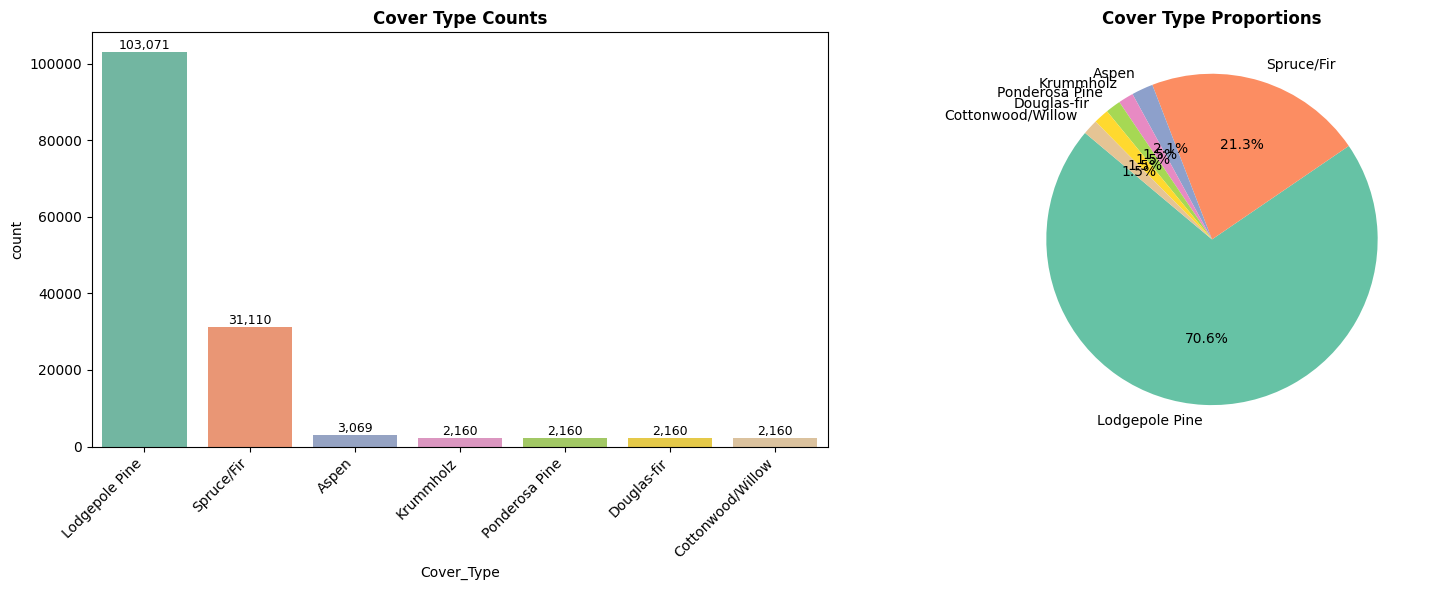

In [3]:
# Cover type distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count plot
order = df['Cover_Type'].value_counts().index
sns.countplot(x='Cover_Type', data=df, order=order, palette='Set2', ax=axes[0])
axes[0].set_title('Cover Type Counts', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Pie chart
counts = df['Cover_Type'].value_counts()
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(counts)))
axes[1].set_title('Cover Type Proportions', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.3 Bivariate Analysis – Feature vs Cover Type

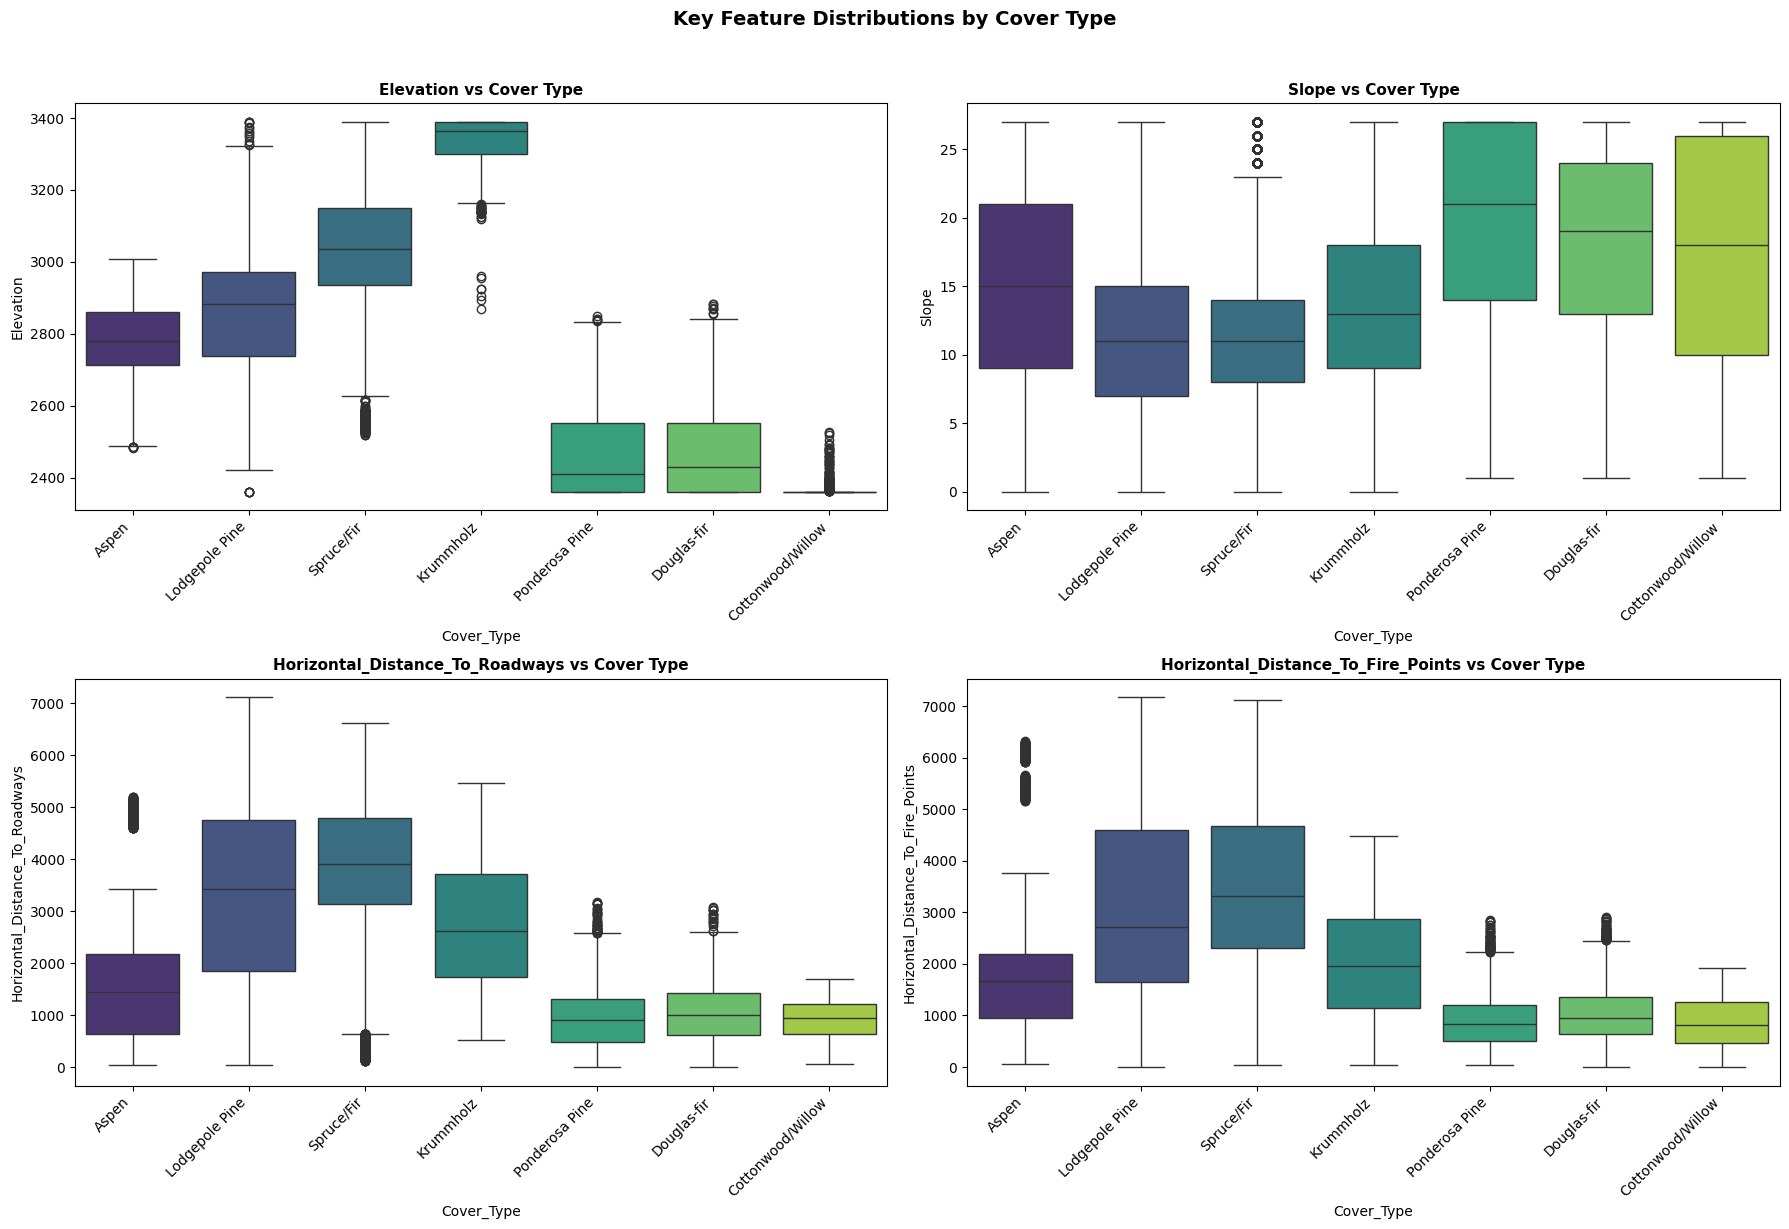

In [4]:
# Boxplots: Key features vs Cover Type
key_features = ['Elevation', 'Slope', 'Horizontal_Distance_To_Roadways',
                'Horizontal_Distance_To_Fire_Points']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    sns.boxplot(x='Cover_Type', y=feat, data=df, palette='viridis', ax=axes[i])
    axes[i].set_title(f'{feat} vs Cover Type', fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
plt.suptitle("Key Feature Distributions by Cover Type", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Key Observations:**
> - **Elevation** is a strong discriminator — different cover types occupy distinct elevation ranges
> - **Krummholz** appears at highest elevations; **Cottonwood/Willow** at lowest
> - Distance to roadways and fire points also vary significantly across cover types

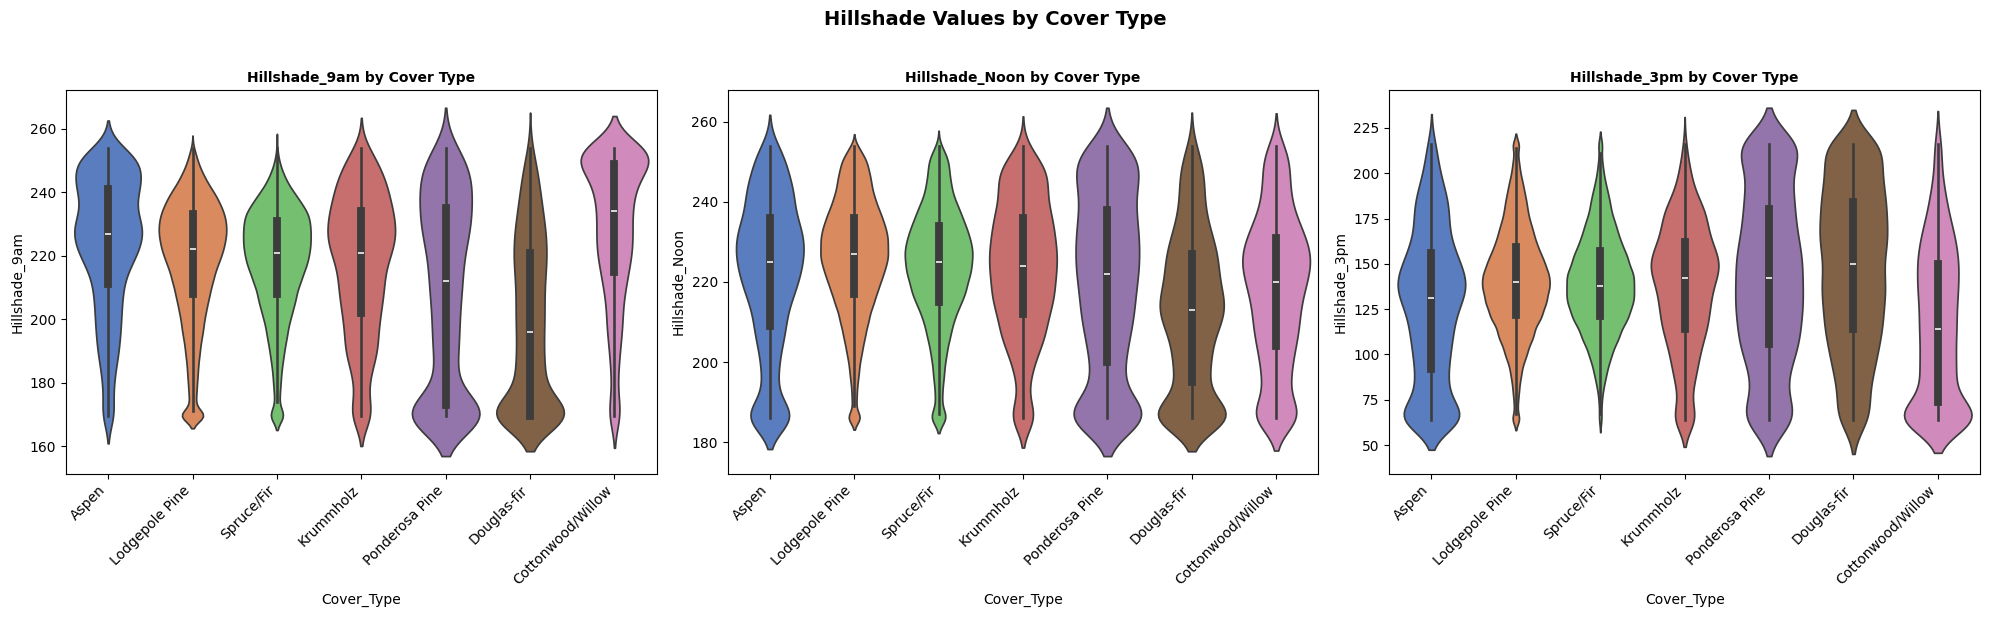

In [5]:
# Violin plots for Hillshade features
hillshade_cols = ['Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, col in enumerate(hillshade_cols):
    sns.violinplot(x='Cover_Type', y=col, data=df, palette='muted', ax=axes[i])
    axes[i].set_title(f'{col} by Cover Type', fontsize=10, fontweight='bold')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
plt.suptitle("Hillshade Values by Cover Type", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Correlation Heatmap

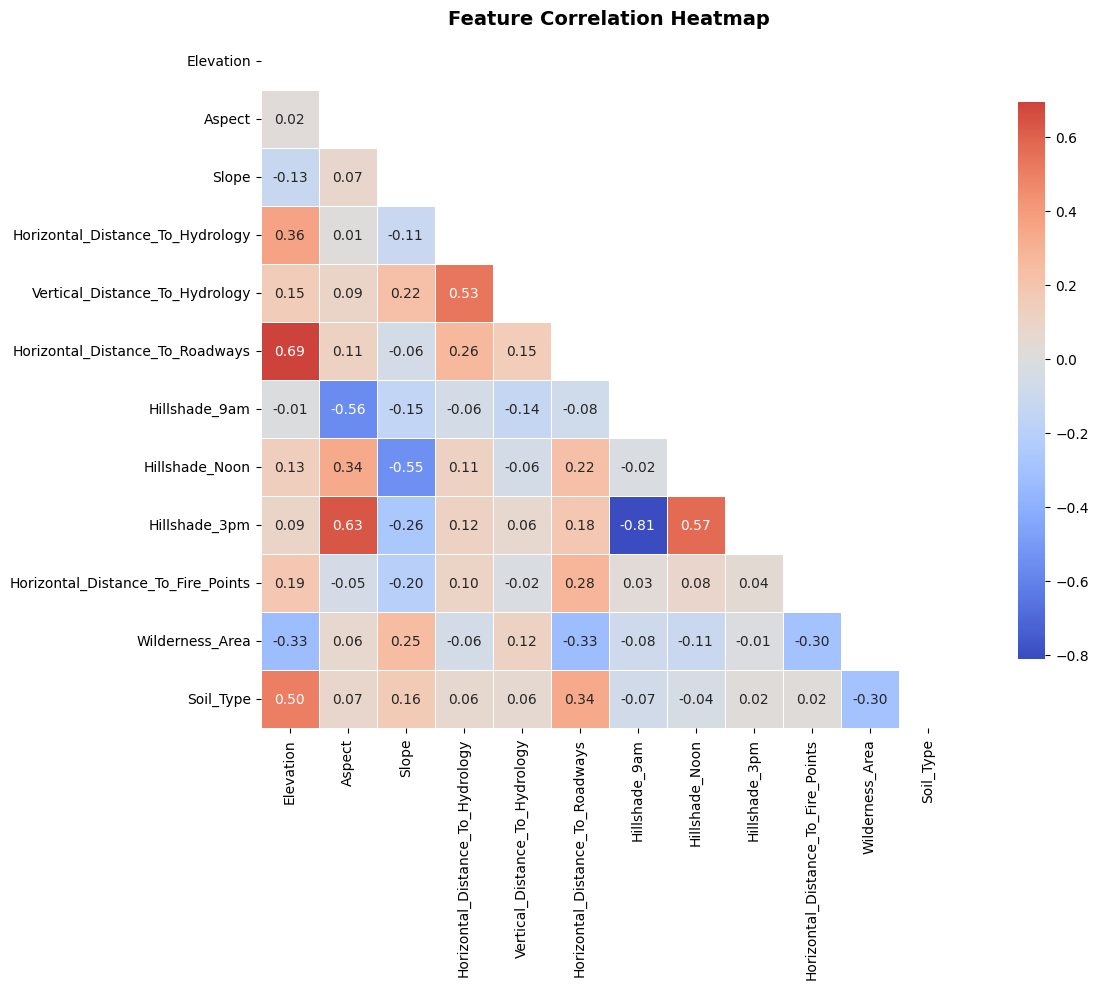

In [6]:
# Correlation matrix
plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Correlation Insights:**
> - Hillshade_9am and Hillshade_3pm show negative correlation (expected: morning vs afternoon sun angles)
> - Horizontal and Vertical distances to hydrology are positively correlated
> - Slope shows correlation with certain hillshade values

### 5.5 Pairplot of Selected Features

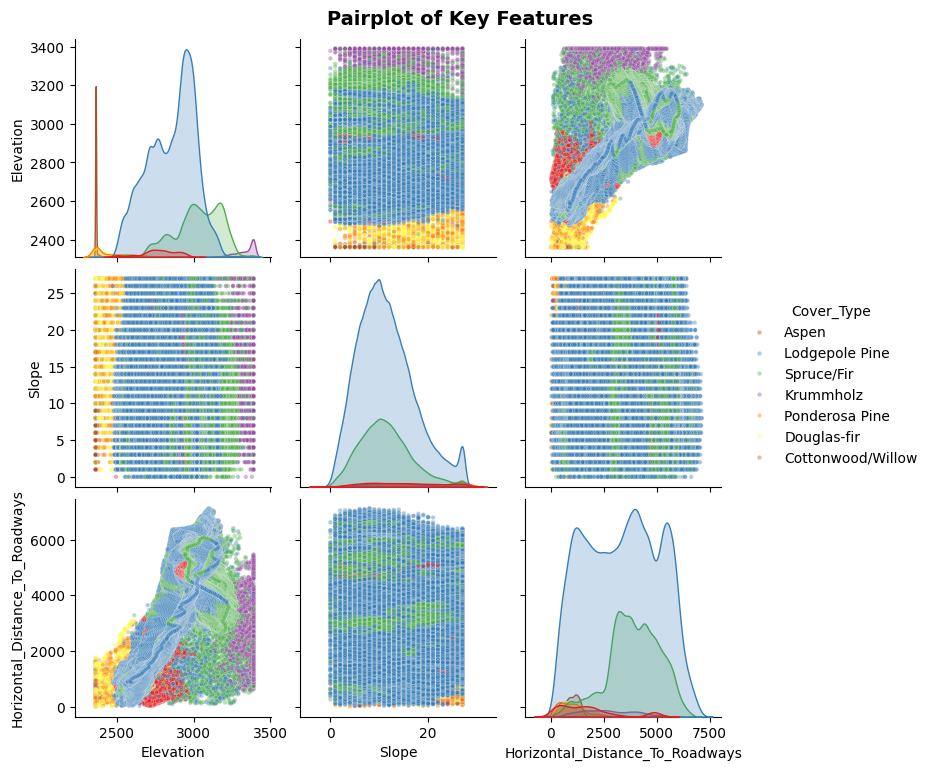

In [7]:
# Pairplot for top discriminating features
selected = ['Elevation', 'Slope', 'Horizontal_Distance_To_Roadways', 'Cover_Type']
sns.pairplot(df[selected], hue='Cover_Type', diag_kind='kde', palette='Set1',
             plot_kws={'alpha': 0.4, 's': 10})
plt.suptitle("Pairplot of Key Features", fontsize=14, fontweight='bold', y=1.02)
plt.show()

### 5.6 Feature Importance (Baseline Random Forest)

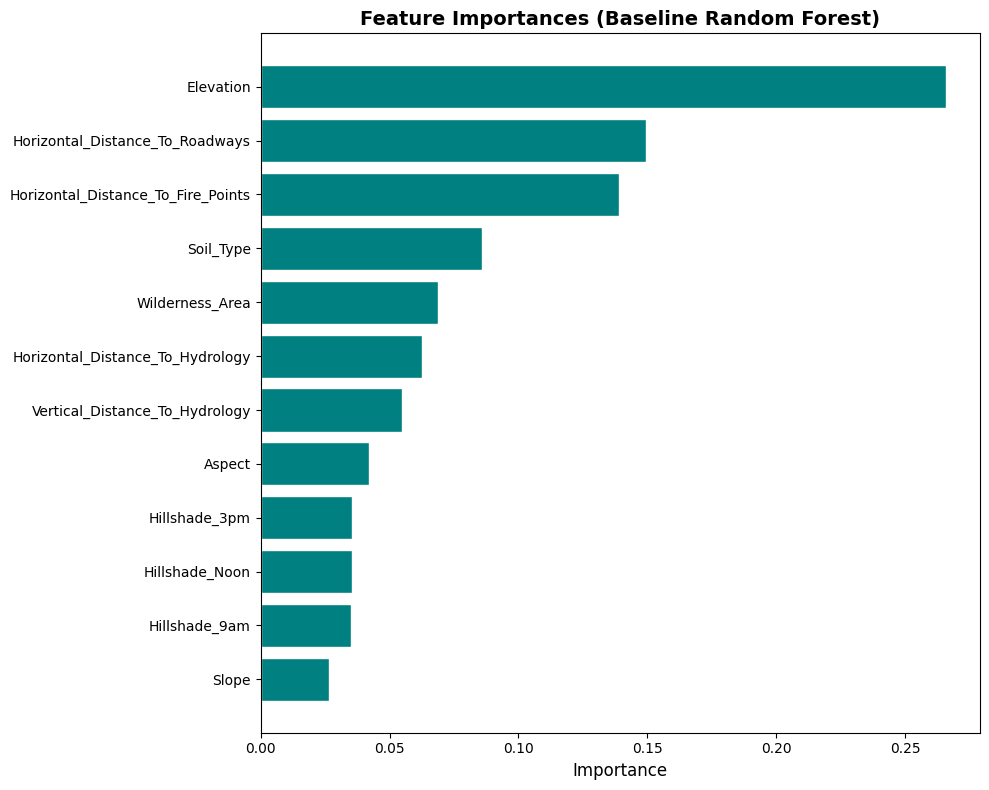


Top 5 Most Important Features:
  Wilderness_Area: 0.0686
  Soil_Type: 0.0858
  Horizontal_Distance_To_Fire_Points: 0.1389
  Horizontal_Distance_To_Roadways: 0.1493
  Elevation: 0.2658


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target for baseline model
le_temp = LabelEncoder()
y_temp = le_temp.fit_transform(df['Cover_Type'])
X_temp = df.drop('Cover_Type', axis=1)

# Fit baseline Random Forest
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_temp, y_temp)

# Feature importances
feat_imp = pd.DataFrame({
    'Feature': X_temp.columns,
    'Importance': rf_baseline.feature_importances_
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='teal', edgecolor='white')
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importances (Baseline Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
for _, row in feat_imp.tail(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

> **Feature Importance Insights:**
> - **Elevation** is by far the most important feature for predicting forest cover type
> - Distance features (hydrology, roadways, fire points) also contribute significantly
> - Hillshade features have moderate importance

---
## 📝 EDA Summary

| Analysis | Key Finding |
|----------|-------------|
| Class Distribution | Severe imbalance – Lodgepole Pine ~70%, Cottonwood/Willow ~1.5% |
| Elevation | Strongest discriminator across cover types |
| Correlations | Hillshade_9am and 3pm negatively correlated; Hydrology distances positively correlated |
| Feature Importance | Elevation > Distance features > Hillshade features |
| Recommendation | Apply SMOTE/oversampling during training; focus on top features |